## Student Performance Dataset


================= head function ===================

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

================= size of file ===================

8000

================= shape function =============

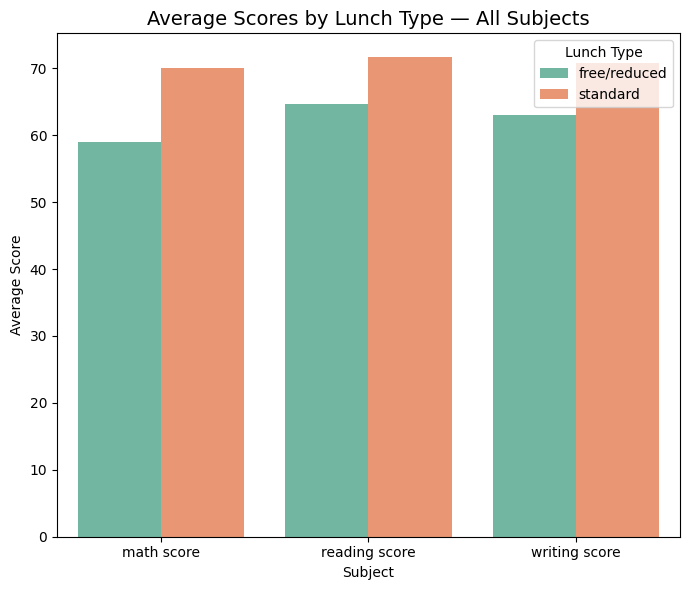

  test preparation course  math score  reading score  writing score
0               completed       69.70          73.89          74.42
1                    none       64.08          66.53          64.50
  test preparation course       subjects  average score
0               completed     math score          69.70
1                    none     math score          64.08
2               completed  reading score          73.89
3                    none  reading score          66.53
4               completed  writing score          74.42
5                    none  writing score          64.50


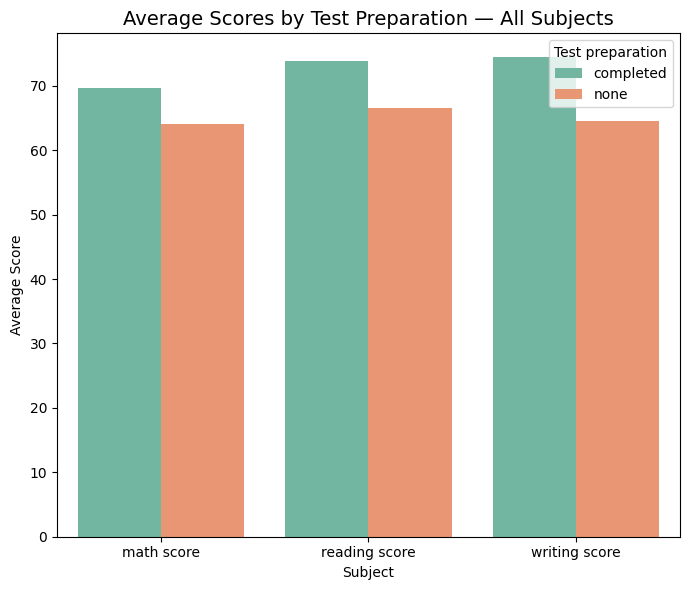

In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# Load file 
df=pd.read_csv("StudentsPerformance.csv")
# basic overview
print("\n================= head function ===================\n")
print(df.head())
print("\n================= size of file ===================\n")
print(df.size)
print("\n================= shape function ===================\n")
print(df.shape)
print("\n================= infomation of file ===================\n")
print(df.info())


# find missing value and duplicates
print("\n===== Missing values per column  :\n",df.isnull().sum())
print("\n===== duplicates values per row : \n",df.duplicated().sum())
print("\n=======Basic Statics======\n")
print(df.describe())


# analyse data 
zero_math=df[df['math score']==0]
print("\n====students with 0 in math sores\n",zero_math)
low_score=df[(df['math score']<10)|
             (df['reading score']<10)|
             (df['writing score']<10)]
print("\n===students with any score below 10\n",low_score)


lunch_anaysis=df.groupby('lunch')[['math score',
                                   'reading score',
                                   'writing score']].mean().round(2)
print("\n======Avarage score by lunch type:\n",lunch_anaysis)

# zender score
zender_score=df.groupby('gender')[['math score','reading score','writing score']].mean().round(2)
print(zender_score)


# prerents level education score of math score 
paretlevel_score=df.groupby('parental level of education')[['math score']].mean().round(2).sort_values('math score', ascending=False)
print(paretlevel_score)


# total education score 
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = (df['total score'] / 3).round(2)
top_10 = df.nlargest(10, 'total score')


# — calculate average scores by lunch type
lunch_analysis = df.groupby('lunch')[['math score',
                                       'reading score',
                                       'writing score']].mean().round(2).reset_index()
#  — melt wide data into long format
lunch_melted = pd.melt(lunch_analysis,
                        id_vars='lunch',
                        value_vars=['math score',
                                    'reading score',
                                    'writing score'],
                        var_name='subject',
                        value_name='average score')
print(lunch_analysis)
print(lunch_melted)

# — plot grouped bar chart
plt.figure(figsize=(7, 6))
sns.barplot(data=lunch_melted,
            x='subject',
            y='average score',
            hue='lunch',
            palette='Set2',
        )
plt.title('Average Scores by Lunch Type — All Subjects', fontsize=14)
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.legend(title='Lunch Type')
plt.tight_layout()
plt.show()



# -calculate avrage scores by test prepraration
test_analysis=df.groupby('test preparation course')[['math score',
                                              'reading score',
                                              'writing score']].mean().round(2).reset_index()
test_melted=pd.melt(test_analysis,
                    id_vars='test preparation course',
                    value_vars=['math score',
                                'reading score',
                                'writing score'],
                    var_name='subjects',
                    value_name='average score'
                    )

print(test_analysis)
print(test_melted)

plt.figure(figsize=(7,6))
sns.barplot(data=test_melted,
            x='subjects',
            y='average score',
            hue='test preparation course',
            palette='Set2')

plt.title('Average Scores by Test Preparation — All Subjects', fontsize=14)
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.legend(title='Test preparation')
plt.tight_layout()
plt.show()


PROJECT: Student Performance Analysis
OBJECTIVE: Identify key factors that affect student exam scores
           and provide recommendations to improve academic outcomes
DATASET: 1000 students | 8 columns | Source: Kaggle
TOOLS: Python (Pandas, NumPy, Matplotlib, Seaborn)


================= First 5 Rows ===================

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

================= Total Data Points ===================

8000

================= Shape of Dataset =======

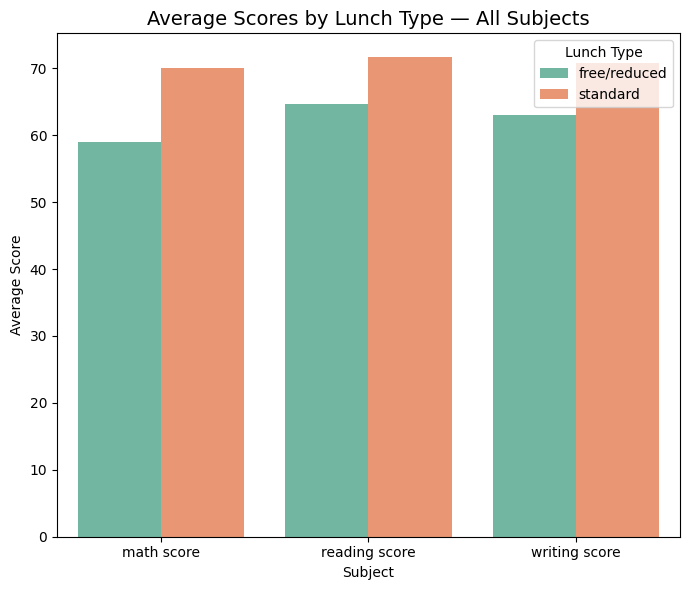


===== Average Score by Test Preparation:
   test preparation course  math score  reading score  writing score
0               completed       69.70          73.89          74.42
1                    none       64.08          66.53          64.50


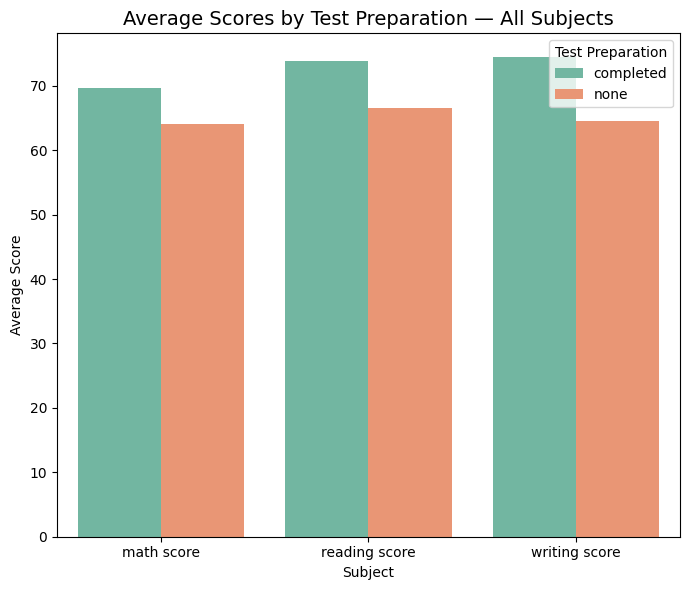


===== Average Score by Gender:
    gender  math score  reading score  writing score
0  female       63.63          72.61          72.47
1    male       68.73          65.47          63.31


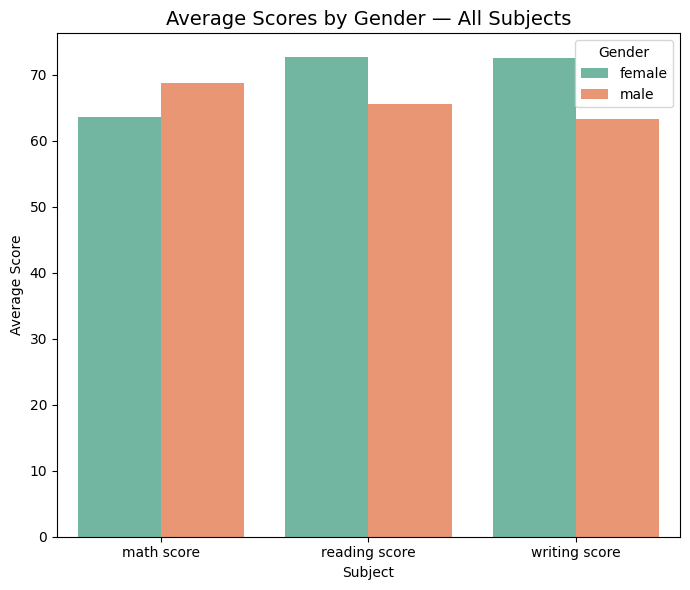


===== Average Math Score by Parental Education:
   parental level of education  math score
0             master's degree       69.75
1           bachelor's degree       69.39
2          associate's degree       67.88
3                some college       67.13
4            some high school       63.50
5                 high school       62.14


C:\Users\DC\AppData\Local\Temp\ipykernel_21272\2073173765.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=parent_analysis,


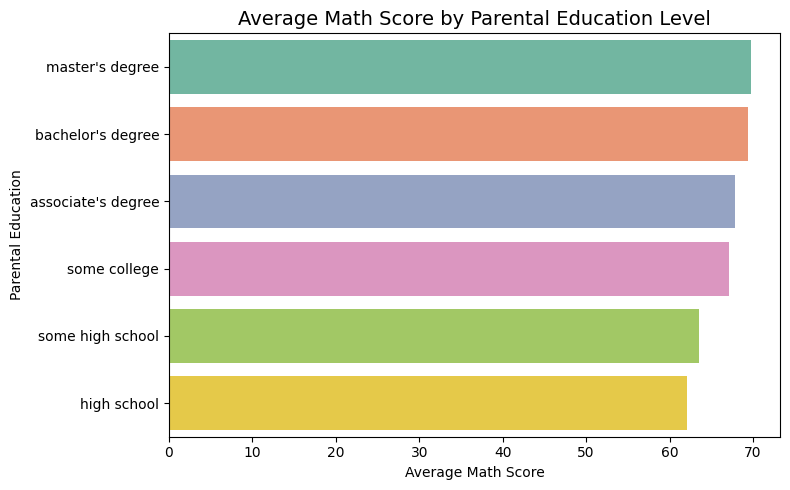


KEY FINDINGS
1. Standard lunch students score ~11 points higher in math
   than free/reduced lunch students

2. Test preparation course completion improves scores
   by 5-8 points across all subjects

3. Male students perform better in math
   Female students lead in reading and writing

4. Higher parental education level is linked
   to better student performance

RECOMMENDATIONS
1. School should increase access to standard lunch programs
2. Make test preparation course mandatory or free for all students
3. Provide additional math support programs for female students
4. Engage parents in academic development programs



In [1]:

# ---- Library Imports ----
import numpy as np                  # numerical operations
import pandas as pd                 # data manipulation
import matplotlib.pyplot as plt     # base visualization
import seaborn as sns               # statistical visualization


# =============================================================
# — LOAD & UNDERSTAND DATA
# =============================================================

df = pd.read_csv("StudentsPerformance.csv")

# First 5 rows — understand structure and column names
print("\n================= First 5 Rows ===================\n")
print(df.head())

# Total number of data points (rows x columns)
print("\n================= Total Data Points ===================\n")
print(df.size)

# Dataset dimensions — how many rows and columns
print("\n================= Shape of Dataset ===================\n")
print(df.shape)

# Data types and memory — check if columns are correct type
print("\n================= Dataset Information ===================\n")
print(df.info())


# =============================================================
# — DATA CLEANING
# Question: Is the data clean enough to analyze?
# =============================================================

# Check for missing values — missing data can skew analysis
print("\n===== Missing Values per Column:\n", df.isnull().sum())

# Check for duplicate rows — duplicates cause incorrect averages
print("\n===== Duplicate Rows:\n", df.duplicated().sum())

# Statistical summary — understand score distribution
print("\n===== Basic Statistics:\n")
print(df.describe())

# Check for suspicious outliers — a score of 0 may be a data entry error
zero_math = df[df['math score'] == 0]
print("\n===== Students with 0 in Math Score:\n", zero_math)

# Check students with any score below 10 — extreme low values need attention
low_score = df[(df['math score'] < 10) |
               (df['reading score'] < 10) |
               (df['writing score'] < 10)]
print("\n===== Students with Any Score Below 10:\n", low_score)


# =============================================================
# STEP 3 — FEATURE ENGINEERING
# Adding new columns to enable deeper analysis
# =============================================================

# Total score — sum of all 3 subjects for overall performance ranking
df['total score'] = df['math score'] + df['reading score'] + df['writing score']

# Average score — single number to represent overall student performance
df['average score'] = (df['total score'] / 3).round(2)

# Top 10 performers — who are the highest scoring students overall?
top_10 = df.nlargest(10, 'total score')
print("\n===== Top 10 Students by Total Score:\n", top_10[['gender', 'lunch', 'test preparation course', 'total score', 'average score']])


# =============================================================
# STEP 4 — ANALYSIS 1
# Question: Do students with standard lunch perform better than
#           students with free/reduced lunch?
# =============================================================

lunch_analysis = df.groupby('lunch')[['math score',
                                      'reading score',
                                      'writing score']].mean().round(2).reset_index()

lunch_melted = pd.melt(lunch_analysis,
                       id_vars='lunch',
                       value_vars=['math score', 'reading score', 'writing score'],
                       var_name='subject',
                       value_name='average score')

print("\n===== Average Score by Lunch Type:\n", lunch_analysis)

plt.figure(figsize=(7, 6))
sns.barplot(data=lunch_melted,
            x='subject',
            y='average score',
            hue='lunch',
            palette='Set2')
plt.title('Average Scores by Lunch Type — All Subjects', fontsize=14)
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.legend(title='Lunch Type')
plt.tight_layout()
plt.show()

# INSIGHT: Students on standard lunch score ~11 points higher in math
# than students on free/reduced lunch — across all 3 subjects consistently


# =============================================================
# STEP 5 — ANALYSIS 2
# Question: Does completing a test preparation course
#           improve student scores?
# =============================================================

test_analysis = df.groupby('test preparation course')[['math score',
                                                        'reading score',
                                                        'writing score']].mean().round(2).reset_index()

test_melted = pd.melt(test_analysis,
                      id_vars='test preparation course',
                      value_vars=['math score', 'reading score', 'writing score'],
                      var_name='subject',
                      value_name='average score')

print("\n===== Average Score by Test Preparation:\n", test_analysis)

plt.figure(figsize=(7, 6))
sns.barplot(data=test_melted,
            x='subject',
            y='average score',
            hue='test preparation course',
            palette='Set2')
plt.title('Average Scores by Test Preparation — All Subjects', fontsize=14)
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.legend(title='Test Preparation')
plt.tight_layout()
plt.show()

# INSIGHT: Students who completed test preparation score ~5-8 points
# higher across all subjects — preparation course clearly has a positive impact


# =============================================================
# STEP 6 — ANALYSIS 3
# Question: Do male and female students perform differently
#           across subjects?
# =============================================================

gender_analysis = df.groupby('gender')[['math score',
                                        'reading score',
                                        'writing score']].mean().round(2).reset_index()

gender_melted = pd.melt(gender_analysis,
                        id_vars='gender',
                        value_vars=['math score', 'reading score', 'writing score'],
                        var_name='subject',
                        value_name='average score')

print("\n===== Average Score by Gender:\n", gender_analysis)

plt.figure(figsize=(7, 6))
sns.barplot(data=gender_melted,
            x='subject',
            y='average score',
            hue='gender',
            palette='Set2')
plt.title('Average Scores by Gender — All Subjects', fontsize=14)
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# INSIGHT: Male students score higher in math, while female students
# outperform in both reading and writing


# =============================================================
# STEP 7 — ANALYSIS 4
# Question: Does parental level of education influence
#           student math performance?
# =============================================================

parent_analysis = df.groupby('parental level of education')[['math score']].mean().round(2).sort_values('math score', ascending=False).reset_index()

print("\n===== Average Math Score by Parental Education:\n", parent_analysis)

plt.figure(figsize=(8, 5))
sns.barplot(data=parent_analysis,
            x='math score',
            y='parental level of education',
            palette='Set2',
            orient='h')
plt.title('Average Math Score by Parental Education Level', fontsize=14)
plt.xlabel('Average Math Score')
plt.ylabel('Parental Education')
plt.tight_layout()
plt.show()

# INSIGHT: Students whose parents hold a master's degree score highest
# in math — parental education level shows a clear positive correlation


# =============================================================
# STEP 8 — KEY FINDINGS & RECOMMENDATIONS
# =============================================================

print("""
================================================
KEY FINDINGS
================================================
1. Standard lunch students score ~11 points higher in math
   than free/reduced lunch students

2. Test preparation course completion improves scores
   by 5-8 points across all subjects

3. Male students perform better in math
   Female students lead in reading and writing

4. Higher parental education level is linked
   to better student performance

================================================
RECOMMENDATIONS
================================================
1. School should increase access to standard lunch programs
2. Make test preparation course mandatory or free for all students
3. Provide additional math support programs for female students
4. Engage parents in academic development programs
================================================
""")